# 5장 3강: 배깅 vs 부스팅 선택과 모델 해석(SHAP)

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 배깅과 부스팅을 비교하고, SHAP으로 앙상블 모델의 예측 근거를 해석합니다.

- Random Forest와 XGBoost의 구조적 차이를 비교합니다.
- 성능과 학습 시간을 확인하여 상황에 맞는 모델 선택 기준을 정리합니다.
- Feature Importance의 특징과 한계를 확인합니다.
- TreeSHAP을 이용해 모델 전체의 **전역 해석**을 수행합니다.
- 특정 주택 한 건의 예측을 **지역 해석**합니다.
- SHAP 값의 부호를 이용하여 각 특성이 예측값을 올렸는지 내렸는지 설명합니다.

> 이 실습에서는 5장 3강 교안에 나온 배깅/부스팅 비교, Feature Importance, SHAP 전역·지역 해석 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- shap
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. Random Forest와 XGBoost를 같은 데이터에서 비교합니다.
5. SHAP은 XGBoost 모델을 대상으로 확인합니다.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


---

# 필수 1. 배깅과 부스팅 비교 및 선택

## 문제 1. Random Forest와 XGBoost를 비교하세요.

### 요구사항

다음 두 모델을 사용합니다.

```python
RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
```

각 모델에 대해 다음을 확인합니다.

1. Train 데이터로 학습합니다.
2. 학습 시간을 측정합니다.
3. Test 데이터를 예측합니다.
4. Test RMSE를 계산합니다.
5. Test R²를 계산합니다.
6. 결과를 하나의 DataFrame으로 정리합니다.

### 확인 포인트

- Random Forest가 배깅 계열이라는 점을 이해했는가?
- XGBoost가 부스팅 계열이라는 점을 이해했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [2]:
# TODO
# Random Forest와 XGBoost의 Test RMSE, Test R², 학습 시간을 비교하세요.
models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05,
                            max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start

    pred = model.predict(X_test)
    results.append({
        "모델": name,
        "학습 시간(초)": elapsed,
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "Test R²": r2_score(y_test, pred)
    })

result_df = pd.DataFrame(results)
display(result_df)

rf = models["Random Forest"]
xgb = models["XGBoost"]

,모델,학습 시간(초),Test RMSE,Test R²
0,Random Forest,0.515736,29206.646630,0.888789
1,XGBoost,2.496155,28405.320065,0.894807


### Q1. Random Forest와 XGBoost의 학습 방식은 어떻게 다른가요?

**답변:**  Random Forest는 배깅 계열이다. 부트스트랩 표본으로 깊은 나무들을 서로 독립적으로 학습하고 예측을 평균낸다. XGBoost는 부스팅 계열이다. 얕은 나무를 순차적으로 추가하면서 이전까지의 예측이 남긴 잔차를 다음 나무가 보완한다. 즉 RF는 여러 모델을 평균내 분산을 줄이는 방식이고, XGBoost는 오차를 단계적으로 줄여 편향을 줄이는 방식이다.

### Q2. 다음 상황에서 어떤 방식을 우선 후보로 생각할 수 있는지 작성하세요.

1. 빠르게 베이스라인을 만들고 싶고 튜닝 여력이 적음
2. 시간을 들여 예측 성능을 더 끌어올리고 싶음
3. 노이즈가 많아 과적합 위험을 조심해야 함

**답변:**  
- 빠르게 베이스라인을 만들고 튜닝 여력이 적다면 Random Forest를 먼저 고려한다. 기본 설정만으로도 성능이 안정적으로 나오고, 하이퍼파라미터에 덜 민감하기 때문이다.
- 시간을 들여 성능을 더 끌어올리고 싶다면 부스팅(XGBoost, LightGBM 등)을 고려한다. learning_rate, max_depth, n_estimators 등을 튜닝하면 더 높은 성능을 낼 여지가 크다.
- 노이즈가 많아 과적합이 걱정된다면 Random Forest를 우선 고려한다. 부스팅은 이전 오차를 계속 맞추려 하다 보니 노이즈까지 학습할 위험이 있지만, 배깅은 평균을 내므로 노이즈 영향이 상대적으로 덜하다.

---

# 필수 2. Feature Importance와 SHAP 전역 해석

## 문제 1. XGBoost의 Feature Importance를 확인하세요.

### 요구사항

1. 필수 1에서 학습한 XGBoost 모델을 사용합니다.
2. `feature_importances_`를 이용합니다.
3. 특성명과 중요도를 DataFrame으로 만듭니다.
4. 중요도가 높은 순서대로 정렬합니다.
5. 막대그래프로 표시합니다.

### 확인 포인트

- 어떤 특성이 모델 전체에서 중요하게 사용되었는지 확인했는가?
- 중요도의 크기는 알 수 있지만 방향은 알 수 없다는 점을 이해했는가?

,feature,importance
0,OverallQual,0.466007
2,GarageCars,0.131052
1,GrLivArea,0.086469
5,1stFlrSF,0.061165
7,FullBath,0.046529
6,2ndFlrSF,0.042468
4,TotalBsmtSF,0.041869
11,Fireplaces,0.040955
10,YearRemodAdd,0.034265
9,YearBuilt,0.027039


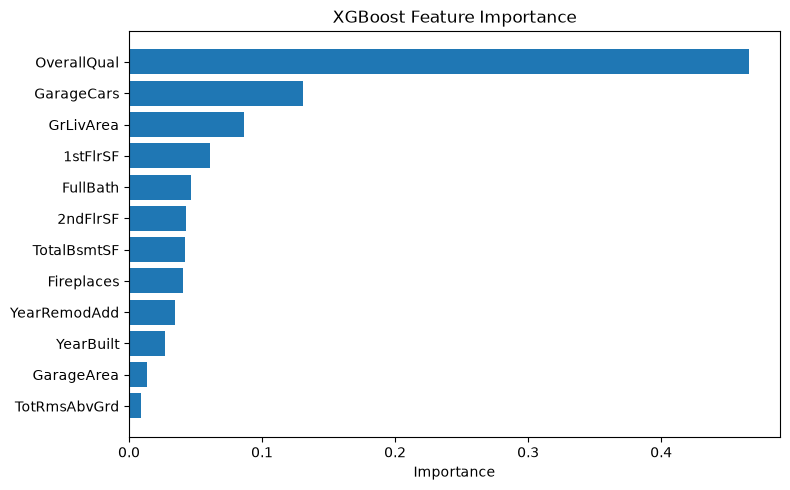

In [3]:
# TODO
# XGBoost의 Feature Importance를 표와 그래프로 확인하세요.
fi_df = pd.DataFrame({
    "feature": features,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

display(fi_df)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["feature"], fi_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

### Q3. Feature Importance만으로는 알기 어려운 정보는 무엇인가요?

**답변:**  Feature Importance로는 중요도의 크기만 알 수 있고, 방향은 알 수 없다. 예를 들어 OverallQual이 중요하다는 것은 알 수 있지만, 값이 높을 때 가격을 올리는지 내리는지는 알 수 없다. 또한 모델 전체 기준의 값이라, 특정 주택 한 건에서 어떤 특성이 얼마나 영향을 줬는지도 알 수 없다.

## 문제 2. TreeSHAP으로 전역 중요도를 확인하세요.

### 요구사항

1. `shap.TreeExplainer()`에 XGBoost 모델을 전달합니다.
2. Test 데이터의 SHAP 값을 계산합니다.
3. `shap.plots.bar()`로 전역 중요도를 확인합니다.
4. SHAP 절댓값의 평균도 계산하여 특성별 중요도를 DataFrame으로 정리합니다.
5. 상위 특성을 확인합니다.

### 확인 포인트

- SHAP은 각 특성이 예측값에 기여한 정도를 계산한다는 점을 이해했는가?
- 전역 SHAP에서는 여러 샘플의 기여도 크기를 종합해 전체 중요도를 볼 수 있는가?

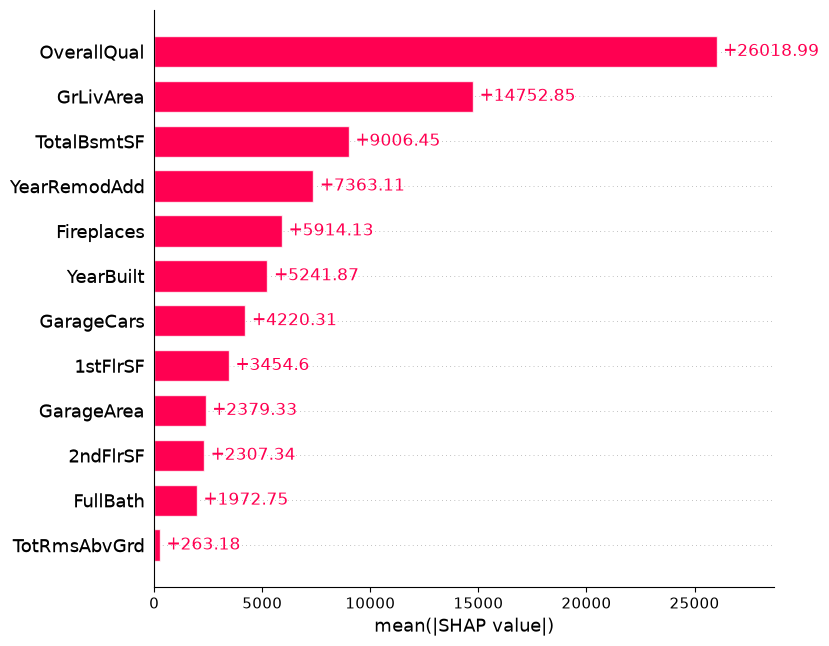

,feature,mean_abs_shap
0,OverallQual,26018.992188
1,GrLivArea,14752.852539
4,TotalBsmtSF,9006.452148
10,YearRemodAdd,7363.110352
11,Fireplaces,5914.131348
9,YearBuilt,5241.869141
2,GarageCars,4220.305664
5,1stFlrSF,3454.599609
3,GarageArea,2379.325684
6,2ndFlrSF,2307.338867


In [4]:
# TODO
# TreeSHAP을 이용해 XGBoost 모델의 전역 SHAP 중요도를 확인하세요.
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

shap.plots.bar(shap_values, max_display=12)

shap_df = pd.DataFrame({
    "feature": features,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_df)

### Q4. Feature Importance와 SHAP의 가장 큰 차이는 무엇인가요?

**답변:**  Feature Importance는 분기에서 오차를 얼마나 줄였는지를 바탕으로 한 모델 전체 기준의 상대적 값이다. 그래서 방향을 알 수 없고 단위도 없다. SHAP은 각 샘플의 예측값에 각 특성이 얼마나 기여했는지를 가격 단위로 계산한다. 부호가 있어 예측을 올렸는지 내렸는지 알 수 있고, 개별 샘플 해석과 전체 평균 해석이 모두 가능하다.

---
# 과제 1. 모델 비교·SHAP 해석과 특성 선택 전후 검증

## 배경
주택 가격 예측 모델을 성능과 학습 시간으로 비교하고, SHAP으로 예측 근거를 설명합니다. 이어서 중요한 특성을 선택했을 때 검증 성능이 어떻게 달라지는지 확인합니다.

> 필수 1·2는 연습용입니다. 아래 과제의 비교표·해석·코드를 제출하세요. 준비 단계의 `X_train`, `y_train`을 사용하되 과제용 모델을 새로 학습합니다. Test 결과로 모델이나 특성을 선택하지 않도록, Train 안에서 Validation을 분리합니다. 개별 주택 해석 대상도 Validation의 첫 번째 주택으로 맞춥니다.

## 요구사항

### 1. 같은 조건에서 모델 비교
1. `X_train`, `y_train`을 Train_sub / Validation으로 나누세요(`test_size=0.2`, `random_state=42`). 결측값이 있으면 Train_sub에서 구한 중앙값으로 두 데이터를 채우세요.
2. Random Forest(`n_estimators=200`)와 XGBoost(`n_estimators=200`, `learning_rate=0.05`, `max_depth=3`)를 같은 Train_sub에서 학습하세요. 두 모델 모두 `random_state=42`, `n_jobs=1`로 설정하세요.
3. 각 모델의 **fit에 걸린 시간**, Train_sub RMSE, Validation RMSE와 R²를 `model_comparison`으로 정리하세요. 시간은 같은 환경에서 측정하며, 한 번의 측정만으로 일반적인 속도 우열을 단정하지 마세요.
4. 예측 오차, 학습 시간, Train/Validation 오차 차이와 운영 목적을 근거로 우선 후보를 선택하세요. 모델 선택 결과와 관계없이 다음 해석은 XGBoost로 수행합니다.

### 2. Feature Importance와 SHAP 전역·지역 해석
5. 과제용 XGBoost의 `feature_importances_`와 **Train_sub의 평균 절댓값 SHAP**을 각각 순위로 정리하여 `importance_comparison`으로 비교하세요. 전역 SHAP 막대그래프도 제출하세요.
6. Validation의 첫 번째 주택의 실제 가격·예측가격을 확인하고 SHAP waterfall plot을 그리세요.
7. 해당 주택의 절댓값 SHAP 상위 5개 특성·특성값·SHAP 값을 `local_top5`로 정리하세요. 양수·음수의 의미를 설명하고 기준값 + 모든 SHAP 값의 합이 예측값과 거의 같은지 확인하세요.
8. 두 전역 중요도 산출 원리와 한계를 비교하고, 전역 순위와 개별 주택의 기여도가 다른 이유를 설명하세요.

### 3. 중요도에 근거한 특성 선택 및 검증
9. Train_sub의 평균 절댓값 SHAP이 높은 **상위 6개 특성**을 선택하세요. 특성 선택은 이번 과제의 특성 개선 시도입니다. 개수는 비교 결과를 보기 전에 6개로 고정합니다.
10. 선택한 특성만 사용하여 동일한 XGBoost 설정으로 다시 학습하세요. 기존 모델과 동일한 Train_sub / Validation 행을 사용하고, 특성 이외의 조건은 유지하세요.
11. 전체 특성 모델과 선택 특성 모델의 특성 수·학습 시간·Train RMSE·Validation RMSE·Validation R²를 `feature_comparison`으로 비교하세요. `기존 Validation RMSE - 선택 후 Validation RMSE`와 기존 대비 개선율(%)을 계산하세요.
12. 개선 여부와 채택 여부를 수치로 설명하세요. 성능이 나빠져도 원인 가능성과 한계를 타당하게 설명하면 됩니다. 검증 결과를 반복 확인하며 특성을 바꾸지 말고, 최종 일반화 성능 확인에는 별도 Test 평가가 필요함을 밝히세요.

## 해석 질문

### Q5. 전역 SHAP에서 가장 중요한 특성이 특정 주택에서도 반드시 가장 큰 영향을 주나요?
### Q6. SHAP 값이 양수/음수라는 것은 각각 무엇을 의미하나요?
### Q7. 두 모델 중 무엇을 우선 후보로 선택했나요? 성능·학습 시간·과적합 징후와 주택 가격 예측 업무를 연결하여 설명하세요.
### Q8. Feature Importance와 평균 절댓값 SHAP의 계산 원리와 한계는 무엇이며, 실제 상위 특성 순위는 어떻게 다른가요?
### Q9. 상위 6개 특성은 무엇이며, 선택 전후 RMSE 차이와 개선율은 얼마인가요? 이 시도를 채택할지와 판단의 한계를 설명하세요.

## 제출물 / 확인 포인트
- `model_comparison`, `importance_comparison`, 전역 SHAP 그래프
- 개별 주택의 실제값·예측값·waterfall plot·`local_top5`·SHAP 합 검증
- 선택한 6개 특성, `feature_comparison`, RMSE 차이와 개선율
- 계산 코드와 Q5~Q9 답변
- 동일한 검증 조건 유지, SHAP의 방향·전역/지역 구분, 관측한 개선 여부와 해석의 한계

In [4]:
# TODO 1: 같은 Train_sub / Validation으로 두 모델의 성능과 fit 시간을 비교하세요.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

medians = X_tr.median()
X_tr = X_tr.fillna(medians)
X_val = X_val.fillna(medians)
print("결측치:", X_tr.isna().sum().sum(), X_val.isna().sum().sum())

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

task_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=1),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        random_state=42, n_jobs=1)
}

rows = []
for name, model in task_models.items():
    start = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - start

    val_pred = model.predict(X_val)
    rows.append({
        "모델": name,
        "fit 시간(초)": fit_time,
        "Train_sub RMSE": rmse(y_tr, model.predict(X_tr)),
        "Validation RMSE": rmse(y_val, val_pred),
        "Validation R²": r2_score(y_val, val_pred)
    })

model_comparison = pd.DataFrame(rows)
model_comparison["Train-Val 차이"] = (
    model_comparison["Validation RMSE"] - model_comparison["Train_sub RMSE"]
)
display(model_comparison)

xgb_task = task_models["XGBoost"]

결측치: 0 0


,모델,fit 시간(초),Train_sub RMSE,Validation RMSE,Validation R²,Train-Val 차이
0,Random Forest,0.403055,12367.658293,29317.762180,0.867024,16950.103887
1,XGBoost,0.031107,19116.641546,27436.846466,0.883539,8320.204920


,FI,FI 순위,평균 |SHAP|,SHAP 순위
OverallQual,0.427782,1,25416.365234,1
GrLivArea,0.078942,3,13777.564453,2
TotalBsmtSF,0.045537,6,9604.813477,3
YearRemodAdd,0.025395,9,7255.513184,4
Fireplaces,0.045971,5,6242.651367,5
YearBuilt,0.034376,7,6187.059570,6
GarageCars,0.205156,2,3490.014404,7
1stFlrSF,0.050895,4,3446.147461,8
GarageArea,0.016150,11,2788.530762,9
2ndFlrSF,0.033605,8,2005.598633,10


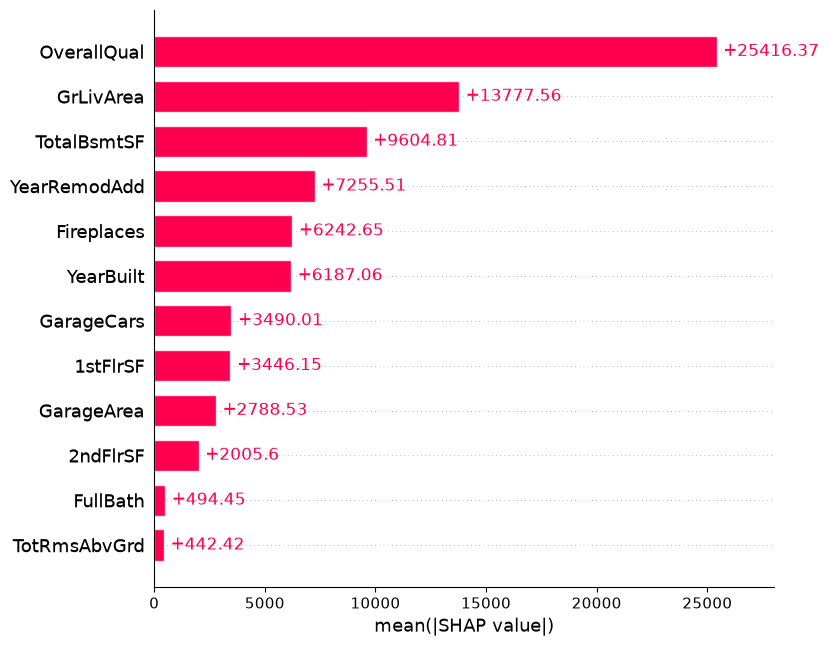

실제 가격: 140,000 / 예측 가격: 149,904


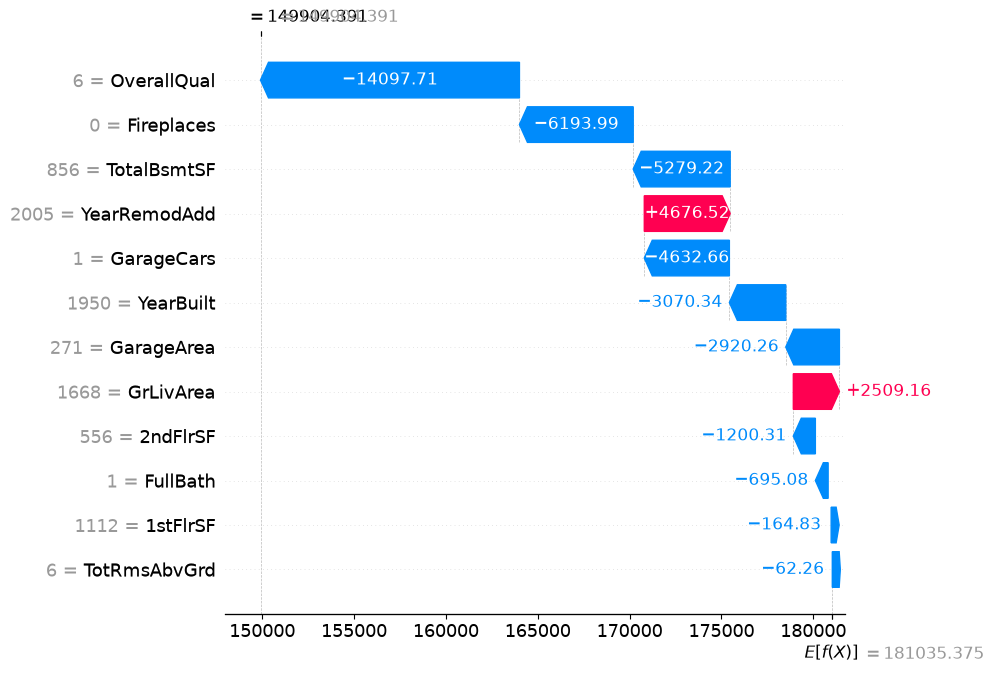

,feature,특성값,SHAP
0,OverallQual,6,-14097.710938
1,Fireplaces,0,-6193.989258
2,TotalBsmtSF,856,-5279.219727
3,YearRemodAdd,2005,4676.523438
4,GarageCars,1,-4632.663086


기준값          : 181,035.38
기준값 + SHAP 합: 149,904.39
모델 예측값     : 149,904.42


In [5]:
# TODO 2: 과제용 XGBoost의 Feature Importance, Train_sub 전역 SHAP, Validation 첫 주택의 지역 SHAP을 확인하세요.
explainer_task = shap.TreeExplainer(xgb_task)
shap_tr = explainer_task(X_tr)

fi = pd.Series(xgb_task.feature_importances_, index=features)
mean_shap = pd.Series(np.abs(shap_tr.values).mean(axis=0), index=features)

importance_comparison = pd.DataFrame({
    "FI": fi,
    "FI 순위": fi.rank(ascending=False).astype(int),
    "평균 |SHAP|": mean_shap,
    "SHAP 순위": mean_shap.rank(ascending=False).astype(int)
}).sort_values("SHAP 순위")
display(importance_comparison)

shap.plots.bar(shap_tr, max_display=12)

house0 = X_val.iloc[[0]]
actual0 = y_val.iloc[0]
pred0 = xgb_task.predict(house0)[0]
print(f"실제 가격: {actual0:,.0f} / 예측 가격: {pred0:,.0f}")

shap_val = explainer_task(X_val)
shap.plots.waterfall(shap_val[0], max_display=12)

local = pd.DataFrame({
    "feature": features,
    "특성값": house0.iloc[0].values,
    "SHAP": shap_val[0].values
})
local_top5 = local.reindex(
    local["SHAP"].abs().sort_values(ascending=False).index
).head(5).reset_index(drop=True)
display(local_top5)

base = float(np.ravel(shap_val[0].base_values)[0])
print(f"기준값          : {base:,.2f}")
print(f"기준값 + SHAP 합: {base + shap_val[0].values.sum():,.2f}")
print(f"모델 예측값     : {pred0:,.2f}")

In [6]:
# TODO 3: Train_sub SHAP 상위 6개 특성으로 재학습하고 동일 Validation에서 전후 성능을 비교하세요.
top6 = mean_shap.sort_values(ascending=False).index[:6].tolist()
print("선택 특성:", top6)

xgb_top6 = XGBRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    random_state=42, n_jobs=1
)
start = time.time()
xgb_top6.fit(X_tr[top6], y_tr)
fit_time6 = time.time() - start

val_pred6 = xgb_top6.predict(X_val[top6])
base_row = model_comparison.set_index("모델").loc["XGBoost"]

feature_comparison = pd.DataFrame([
    {"모델": "전체 특성", "특성 수": len(features),
     "fit 시간(초)": base_row["fit 시간(초)"],
     "Train RMSE": base_row["Train_sub RMSE"],
     "Validation RMSE": base_row["Validation RMSE"],
     "Validation R²": base_row["Validation R²"]},
    {"모델": "상위 6개", "특성 수": len(top6),
     "fit 시간(초)": fit_time6,
     "Train RMSE": rmse(y_tr, xgb_top6.predict(X_tr[top6])),
     "Validation RMSE": rmse(y_val, val_pred6),
     "Validation R²": r2_score(y_val, val_pred6)}
])
display(feature_comparison)

diff = feature_comparison.loc[0, "Validation RMSE"] - feature_comparison.loc[1, "Validation RMSE"]
rate = diff / feature_comparison.loc[0, "Validation RMSE"] * 100
print(f"RMSE 차이(기존 - 선택 후): {diff:,.0f}")
print(f"개선율: {rate:.2f}%")

선택 특성: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearRemodAdd', 'Fireplaces', 'YearBuilt']


,모델,특성 수,fit 시간(초),Train RMSE,Validation RMSE,Validation R²
0,전체 특성,12,0.031107,19116.641546,27436.846466,0.883539
1,상위 6개,6,0.021131,20282.480322,30029.857143,0.860486


RMSE 차이(기존 - 선택 후): -2,593
개선율: -9.45%


## Q5~Q9 답변

- Q5: 반드시 그렇지는 않다. 전역 SHAP은 여러 주택의 |SHAP|을 평균낸 값이라 "평균적으로" 영향이 큰 특성을 보여준다. 개별 주택에서는 그 주택의 특성값에 따라 기여도가 달라진다. 이번 주택에서는 OverallQual이 1위로 같았다. 하지만 전역 5위였던 Fireplaces가 2위였고, 전역 2위인 GrLivArea는 상위 5개에 들지 않았다. 이 주택의 벽난로가 0개라 평균보다 크게 벗어났기 때문에 Fireplaces의 영향이 커진 것으로 보인다.
- Q6: SHAP 값이 양수이면 그 특성이 예측값을 기준값(평균 예측)보다 올렸다는 뜻이고, 음수이면 내렸다는 뜻이다. 예를 들어 이번 주택의 OverallQual SHAP은 −14,098인데, 품질 6이 평균보다 낮은 편이라 예측가격을 약 14,000 낮췄다는 의미다. 반대로 YearRemodAdd는 +4,677로, 최근 리모델링이 가격을 올렸다.
- Q7: XGBoost를 우선 후보로 선택했다. Validation RMSE가 27,437로 RF(29,318)보다 약 1,900 낮고, R2도 0.884로 더 높다. Train-Val 차이도 RF는 약 17,000인 반면 XGBoost는 약 8,300이라, RF 쪽의 과적합 징후가 더 크다. fit 시간도 이번 측정에서는 XGBoost가 더 짧았는데, 한 번 측정한 결과라 속도 우열을 단정하기는 어렵다. 주택 가격 예측은 가격 오차가 곧 금액 손실로 이어지므로 예측 정확도가 중요하다. 또한 매물 데이터가 계속 들어와 재학습이 자주 필요할 수 있어서 학습이 가벼운 점도 장점이다. 다만 Validation 234건 한 번의 결과라, 교차검증으로 한 번 더 확인하는 것이 좋다.
- Q8: Feature Importance는 그 특성으로 분기했을 때 손실이 얼마나 줄었는지를 합쳐서 비율로 나타낸 것이다. 학습 과정 기준이라 방향을 알 수 없다. 또한 상관이 높은 특성끼리 중요도가 한쪽으로 몰릴 수 있다. 평균 SHAP은 각 샘플의 예측에서 특성이 기여한 금액의 절댓값을 평균낸 것이라 실제 예측에 미친 영향 크기를 보여준다. 다만 절댓값을 쓰기 때문에 전역 그래프만으로는 방향을 알 수 없고, 인과관계를 의미하지도 않는다. 실제 순위를 보면 둘 다 OverallQual이 1위였다. 하지만 GarageCars는 FI에서 2위, SHAP에서 7위로 차이가 가장 컸다. 반대로 YearRemodAdd는 FI 9위에서 SHAP 4위로 올라갔다. GarageCars는 몇 번의 분기에서 손실을 크게 줄였지만, 실제 예측값을 움직이는 정도는 크지 않았던 것으로 보인다. GarageArea와 정보가 겹치는 것도 원인일 수 있다.
- Q9: 상위 6개 특성은 OverallQual, GrLivArea, TotalBsmtSF, YearRemodAdd, Fireplaces, YearBuilt다. Validation RMSE는 27,437에서 30,030으로 2,593 증가했고, 개선율은 −9.45%로 성능이 나빠졌다. R2도 0.884에서 0.860으로 떨어졌다. fit 시간은 조금 줄었지만, 특성이 12개라 원래도 가벼워서 큰 의미는 없다. 따라서 이 특성 선택은 채택하지 않는다.

## 3강. 배깅 vs 부스팅 선택과 SHAP

같은 데이터에서 RF와 XGBoost를 비교했더니 XGBoost가 Validation RMSE가 더 낮았고(27,437 vs 29,318), Train-Val 차이도 작아 과적합 징후가 덜했다. 일반적인 선택 기준은 다음과 같다.

| 상황 | 우선 후보 |
|---|---|
| 빠른 베이스라인, 튜닝 여력 적음 | 랜덤포레스트 |
| 시간을 들여 성능 극대화 | 부스팅 (XGBoost, LightGBM 등) |
| 노이즈가 많아 과적합이 걱정됨 | 랜덤포레스트 |

**SHAP**은 각 샘플의 예측값을 "기준값 + 특성별 기여도의 합"으로 분해한다. 양수는 예측을 올렸다는 뜻이고, 음수는 내렸다는 뜻이다. 실습에서 기준값 + SHAP 합(149,904.39)과 예측값(149,904.42)이 거의 같은 것을 확인했다. 여러 샘플의 |SHAP|을 평균내면 **전역 해석**, 샘플 하나를 보면 **지역 해석**이 된다. 전역 1위 특성이 개별 주택에서도 항상 1위는 아니다.

Feature Importance와 SHAP의 순위는 다를 수 있다. GarageCars는 FI 2위였지만 SHAP 7위였다. 또 SHAP 상위 6개 특성만 골라 재학습했더니 오히려 RMSE가 9.45% 나빠졌다. 중요도가 낮은 특성도 다른 특성이 설명하지 못하는 정보를 갖고 있을 수 있다는 뜻이다.

---

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 배깅과 부스팅의 학습 방식 차이는 무엇인가요?
2. 배깅과 부스팅은 각각 편향과 분산 중 무엇을 줄이는 데 초점을 두나요?
3. 튜닝 여력이 부족한 상황에서는 어떤 모델군을 먼저 고려할 수 있나요?
4. Feature Importance의 가장 큰 한계는 무엇인가요?
5. SHAP의 전역 해석과 지역 해석은 무엇이 다른가요?
6. SHAP 값의 양수와 음수는 무엇을 의미하나요?

- 배깅은 여러 모델을 독립적으로(병렬로) 학습해 평균내고, 부스팅은 이전 모델의 오차를 보완하며 순차적으로 학습한다.
- 배깅은 주로 분산을, 부스팅은 주로 편향을 줄이는 데 초점을 둔다.
- 튜닝 여력이 부족하면 기본값으로도 안정적인 Random Forest(배깅 계열)를 먼저 고려한다.
- Feature Importance는 중요도의 크기만 알려주고, 방향(올리는지 내리는지)과 개별 샘플 단위의 영향은 알려주지 않는다.
- 전역 해석은 여러 샘플의 SHAP을 종합해 모델 전체에서 중요한 특성을 보는 것이고, 지역 해석은 특정 샘플 하나의 예측이 왜 그렇게 나왔는지 특성별 기여도로 설명하는 것이다.
- SHAP 값이 양수면 예측값을 기준값보다 올렸다는 뜻이고, 음수면 내렸다는 뜻이다.